* This script sets up the foundation for EDA by checking data integrity,
summarizing statistics, and visualizing key trends.

In [99]:
# load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
# Load the data
file_path = "/content/mmm_sample_data.csv"
df = pd.read_csv(file_path, parse_dates=["date"])  # Ensure 'date' is parsed correctly

*   Check data integrity

In [101]:
# Show the first few rows
display(df.head())

,date,tv,radio,ooh,meta,google,tiktok,digital,sales,holiday
0,2023-01-01,0.00,8385.15,0.00,26733.64,33249.96,20297.92,5902.24,1.128922e+08,1.0
1,2023-01-02,11745.53,0.00,1370.78,5691.95,9004.21,6698.35,1451.42,1.307424e+07,0.0
2,2023-01-03,11154.62,1622.75,1370.14,3740.77,9048.32,4579.36,1312.01,1.137862e+07,0.0
3,2023-01-04,10080.88,749.34,2166.36,4064.67,9103.77,3626.17,1260.37,1.028290e+07,0.0
4,2023-01-05,0.00,1148.37,1646.94,3837.46,6412.06,3462.52,1204.00,8.766587e+06,NaN


In [102]:
# Data types and missing values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 804 entries, 0 to 803
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     790 non-null    datetime64[ns]
 1   tv       775 non-null    float64       
 2   radio    777 non-null    float64       
 3   ooh      775 non-null    float64       
 4   meta     788 non-null    float64       
 5   google   784 non-null    float64       
 6   tiktok   782 non-null    float64       
 7   digital  785 non-null    float64       
 8   sales    782 non-null    float64       
 9   holiday  743 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 62.9 KB


None

In [103]:
# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Solve duplicates
df = df.drop_duplicates()
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows after drop duplicates: {duplicate_count}")

Number of duplicate rows: 36
Number of duplicate rows after drop duplicates: 0


In [104]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

Missing Values:
 date       14
tv         29
radio      27
ooh        29
meta       16
google     20
tiktok     22
digital    19
sales      22
holiday    59
dtype: int64


In [105]:
# Filter rows with null date
rows_with_null_date = df[df["date"].isnull()]

# Display the rows
rows_with_null_date.head()

,date,tv,radio,ooh,meta,google,tiktok,digital,sales,holiday
767,NaT,10633.45,1749.64,NaN,NaN,NaN,NaN,3013.64,26616678.99,0.0
768,NaT,NaN,NaN,789.2,NaN,NaN,4357.36,NaN,6896556.93,NaN
769,NaT,0.00,1936.17,NaN,3490.03,9209.06,8283.00,1855.64,11667766.36,0.0
771,NaT,NaN,996.42,0.0,9974.41,17345.57,16398.21,3795.16,46513263.16,NaN
772,NaT,NaN,0.00,0.0,3367.11,NaN,4721.78,NaN,5344201.04,0.0


In [106]:
# Drop rows with null date
df = df.dropna(subset=['date'])

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

Missing Values:
 tv         21
radio      19
ooh        23
meta       10
google     14
tiktok     15
digital    11
sales      16
holiday    52
dtype: int64


In [107]:
# Filter rows with the same date and order by date
duplicate_dates = df[df.duplicated(subset=['date'], keep=False)].sort_values('date')

# Display the rows with duplicate dates
duplicate_dates.head()

,date,tv,radio,ooh,meta,google,tiktok,digital,sales,holiday
58,2023-02-28,9519.13,1040.05,0.00,3788.81,7886.81,7692.52,1691.76,11505228.29,0.0
800,2023-02-28,9519.13,1040.05,0.00,3788.81,NaN,NaN,NaN,NaN,NaN
770,2023-03-13,0.00,1645.52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,2023-03-13,0.00,1645.52,1555.07,4321.81,8761.16,4189.89,1507.98,9449790.09,0.0
87,2023-03-29,11171.86,925.89,0.00,6096.58,8019.53,6681.11,1583.67,14218487.25,0.0


In [110]:
# Group by date and find the number of NaN values in each group
nan_counts = df.groupby('date')['date'].apply(lambda x: x.isnull().sum().sum())

# Find rows with the same date
duplicate_dates = df[df.duplicated(subset=['date'], keep=False)]

# Iterate through each date with duplicates
dates_to_drop = []
for date in duplicate_dates['date'].unique():
    # Get rows with the current date
    rows = df[df['date'] == date]

    # Find rows with maximum NaN values
    max_nan_count = rows.isnull().sum(axis=1).max()
    rows_to_drop = rows[rows.isnull().sum(axis=1) == max_nan_count]

    # Add indices to drop
    dates_to_drop.extend(rows_to_drop.index)

# Drop rows with maximum NaN values for each duplicate date
df_cleaned = df.drop(dates_to_drop)

# Resulting cleaned dataframe
df = df_cleaned

# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

Missing Values:
 tv          7
radio       6
ooh        11
sales       4
holiday    36
dtype: int64


In [111]:
# Fill missing values for TV, radio, ooh, and holiday with 0
df[['tv', 'radio', 'ooh', 'holiday']] = df[['tv', 'radio', 'ooh', 'holiday']].fillna(0)

# Interpolate missing sales values
df['sales'] = df['sales'].interpolate(method='linear')

# Verify if there are any remaining missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values[missing_values > 0])

Missing Values:
 Series([], dtype: int64)


In [113]:
# Data types and missing values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 730 entries, 0 to 729
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     730 non-null    datetime64[ns]
 1   tv       730 non-null    float64       
 2   radio    730 non-null    float64       
 3   ooh      730 non-null    float64       
 4   meta     730 non-null    float64       
 5   google   730 non-null    float64       
 6   tiktok   730 non-null    float64       
 7   digital  730 non-null    float64       
 8   sales    730 non-null    float64       
 9   holiday  730 non-null    float64       
dtypes: datetime64[ns](1), float64(9)
memory usage: 62.7 KB


None

In [114]:
# Summary statistics
display(df.describe())

,date,tv,radio,ooh,meta,google,tiktok,digital,sales,holiday
count,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,7.300000e+02,730.000000
mean,2023-12-31 12:00:00,10708.626863,1518.868493,1359.509438,7963.714315,13669.758973,11166.295507,3261.004685,5.908359e+07,0.027397
min,2023-01-01 00:00:00,0.000000,0.000000,0.000000,2553.030000,4755.040000,2426.470000,1014.490000,4.745660e+06,0.000000
25%,2023-07-02 06:00:00,5082.660000,687.652500,526.102500,4559.082500,7792.047500,5175.460000,1660.515000,1.164217e+07,0.000000
50%,2023-12-31 12:00:00,8496.505000,1166.845000,1042.440000,5695.695000,9773.955000,7597.270000,2596.560000,2.094149e+07,0.000000
75%,2024-06-30 18:00:00,10865.755000,1786.387500,1719.932500,7954.150000,12571.972500,11117.090000,3238.200000,4.082251e+07,0.000000
max,2024-12-30 00:00:00,79547.540000,13935.830000,11482.260000,62314.090000,150701.980000,147079.350000,31413.410000,2.136092e+09,1.000000
std,NaN,10275.094267,1572.827353,1417.028930,6967.629984,13228.616961,12187.681013,3112.986023,1.386678e+08,0.163350


In [115]:
# Check for zeros in specific columns and calculate their share
# Select all columns except 'date' and 'holidays'
columns_to_check = [col for col in df.columns if col not in ["date", "holiday"]]
zero_counts = (df[columns_to_check] == 0).sum()

# Calculate the share of zeros for each column
zero_shares = (zero_counts / len(df)) * 100

# Print columns with zero values and their shares
print("Zero Values and Shares:\n")
for column, count, share in zip(zero_counts.index, zero_counts.values, zero_shares.values):
    if count > 0:
        print(f"{column}: {count} zeros ({share:.2f}%)")

Zero Values and Shares:

tv: 113 zeros (15.48%)
radio: 142 zeros (19.45%)
ooh: 158 zeros (21.64%)


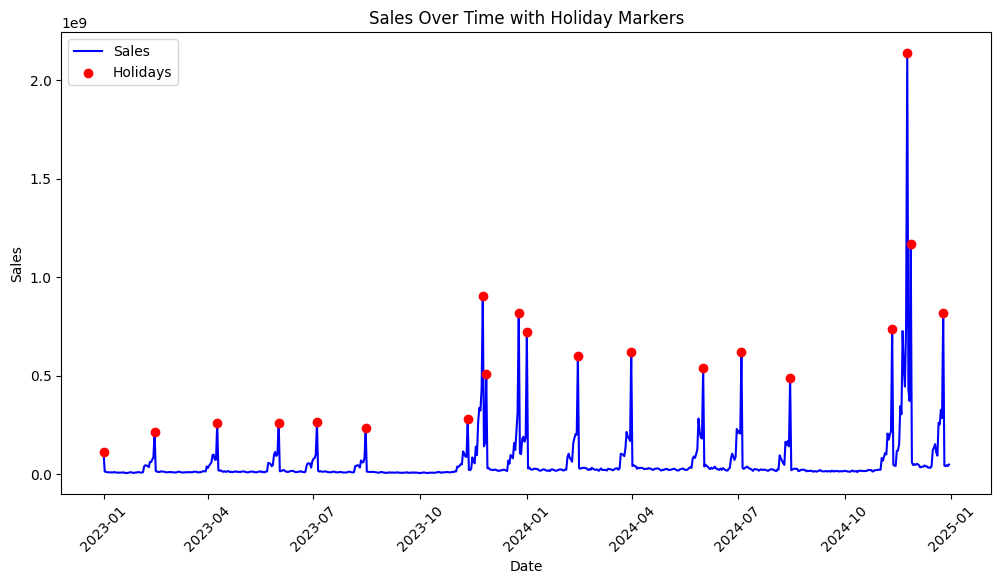

In [116]:
# Plot time-series trends with holiday markers
plt.figure(figsize=(12, 6))
sns.lineplot(x=df["date"], y=df["sales"], label="Sales", color="blue")

# Highlight holiday dates
df_holidays = df[df["holiday"] == 1]  # Assuming 'holiday' column marks holidays
plt.scatter(df_holidays["date"], df_holidays["sales"], color="red", label="Holidays", zorder=3)

plt.title("Sales Over Time with Holiday Markers")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.show()


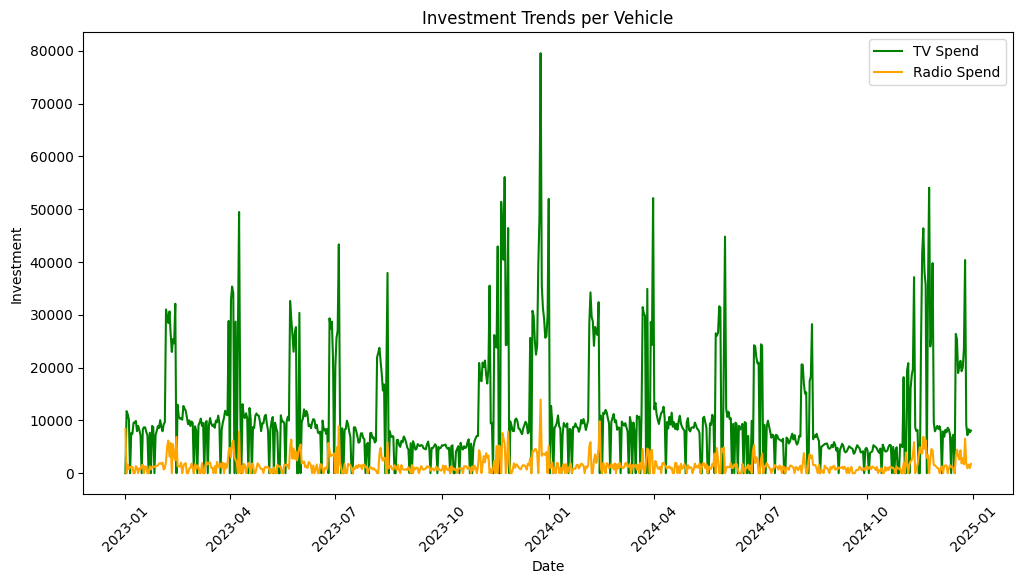

In [117]:
# Plot investment trends per vehicle
plt.figure(figsize=(12, 6))
sns.lineplot(x=df["date"], y=df["tv"], label="TV Spend", color="green")
sns.lineplot(x=df["date"], y=df["radio"], label="Radio Spend", color="orange")
plt.title("Investment Trends per Vehicle")
plt.xlabel("Date")
plt.ylabel("Investment")
plt.xticks(rotation=45)
plt.legend()
plt.show()

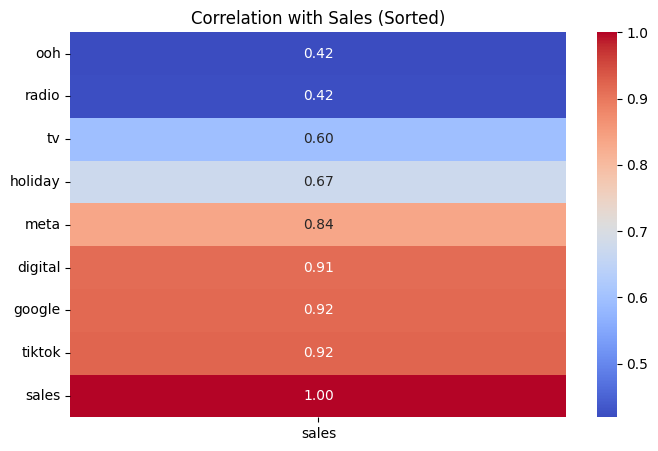

In [118]:
# Correlation heatmap (with selected columns, only against sales)

selected_columns = [col for col in df.columns if col not in ["date"]]
correlations = df[selected_columns].corr()[['sales']].sort_values(by=['sales'])  # Sort by sales correlation

plt.figure(figsize=(8, 5))
sns.heatmap(correlations, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation with Sales (Sorted)")
plt.show()